# Part 1a: Regularization Techniques in TensorFlow/Keras

This notebook demonstrates various regularization techniques to prevent overfitting in neural networks using TensorFlow/Keras. We'll compare models with and without regularization (A/B testing) to see the impact.

## Topics Covered:
1. L1 Regularization (Lasso)
2. L2 Regularization (Ridge)
3. L1+L2 Regularization (Elastic Net)
4. Dropout
5. Early Stopping
6. Batch Normalization

**Author:** Advanced Deep Learning Course Assignment

## Setup and Imports

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons, make_classification
import warnings
warnings.filterwarnings('ignore')

# Check TensorFlow version
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Load and Prepare Data

We'll use the MNIST dataset for our experiments. We'll intentionally use a small subset to increase the chance of overfitting, which will help us demonstrate the effectiveness of regularization.

In [3]:
# Load MNIST dataset
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Flatten images for dense network
X_train_full = X_train_full.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Use a smaller subset to demonstrate overfitting
X_train_small = X_train_full[:5000]
y_train_small = y_train_full[:5000]

# Split into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_small, y_train_small, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set size: 4000
Validation set size: 1000
Test set size: 10000


## Helper Functions

Let's create helper functions for training and plotting results.

In [4]:
def plot_training_history(histories, titles):
    """
    Plot training and validation accuracy/loss for multiple models.

    Args:
        histories: List of Keras History objects
        titles: List of model names for the legend
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot accuracy
    for history, title in zip(histories, titles):
        axes[0].plot(history.history['accuracy'], label=f'{title} - Train')
        axes[0].plot(history.history['val_accuracy'], '--', label=f'{title} - Val')
    axes[0].set_title('Model Accuracy Comparison')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot loss
    for history, title in zip(histories, titles):
        axes[1].plot(history.history['loss'], label=f'{title} - Train')
        axes[1].plot(history.history['val_loss'], '--', label=f'{title} - Val')
    axes[1].set_title('Model Loss Comparison')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate model and print results.
    """
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"{model_name}: Test Loss = {loss:.4f}, Test Accuracy = {accuracy:.4f}")
    return loss, accuracy

---
## 1. Baseline Model (No Regularization)

First, let's create a baseline model without any regularization to see how it performs and whether it overfits.

In [5]:
def create_baseline_model():
    """
    Create a baseline neural network without any regularization.
    This model is intentionally complex to demonstrate overfitting.
    """
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create and train baseline model
print("Training Baseline Model (No Regularization)...")
baseline_model = create_baseline_model()
baseline_model.summary()

Training Baseline Model (No Regularization)...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 317,450 (1.21 MB)

 Trainable params: 317,450 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the baseline model
baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7940 - loss: 0.6614 - val_accuracy: 0.8930 - val_loss: 0.3669
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9270 - loss: 0.2316 - val_accuracy: 0.9130 - val_loss: 0.2852
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9585 - loss: 0.1336 - val_accuracy: 0.9150 - val_loss: 0.3167
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9715 - loss: 0.0942 - val_accuracy: 0.9280 - val_loss: 0.3200
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9737 - loss: 0.0698 - val_accuracy: 0.9360 - val_loss: 0.3542
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9787 - loss: 0.0669 - val_accuracy: 0.9380 - val_loss: 0.2889
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9852 - loss: 0.0404 - val_accuracy: 0.9230 - val_loss: 0.3437
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9865 - loss: 0.0346 - val_accuracy: 0

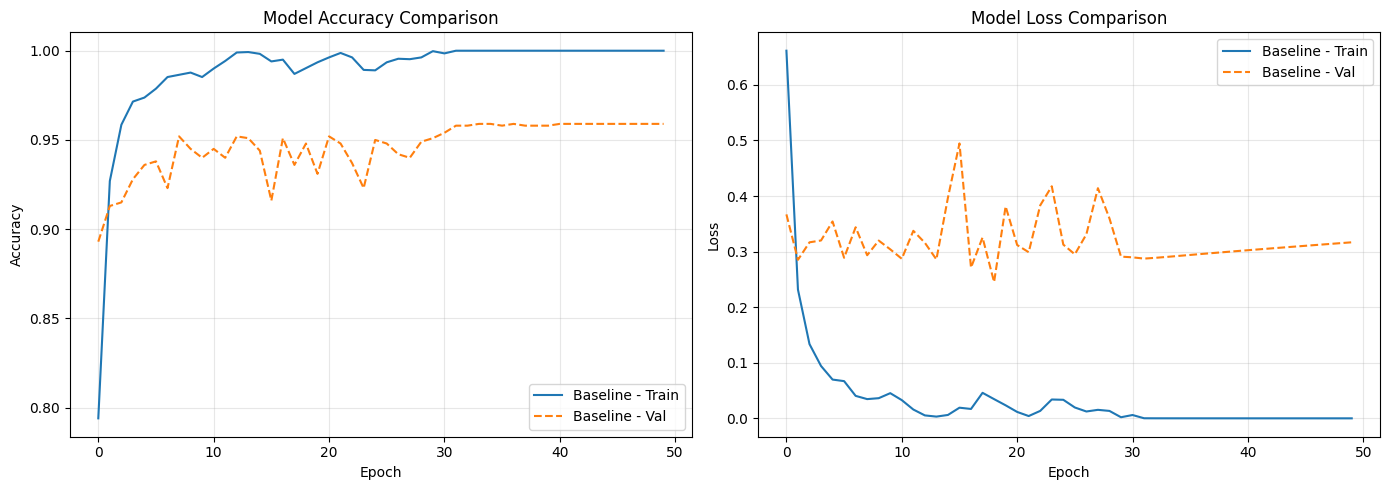

In [7]:
# Plot baseline results
plot_training_history([baseline_history], ['Baseline'])

# Notice the gap between training and validation curves - this indicates OVERFITTING

---
## 2. L1 Regularization (Lasso)

L1 regularization adds the absolute value of weights to the loss function. This encourages **sparsity** - many weights become exactly zero, effectively performing feature selection.

**Mathematical formulation:**
$$\text{Loss}_{L1} = \text{Loss}_{original} + \lambda \sum_{i} |w_i|$$

**When to use:**
- When you want automatic feature selection
- When you believe many features are irrelevant
- Creates sparse models that are easier to interpret

In [8]:
def create_l1_model(l1_strength=0.001):
    """
    Create a model with L1 regularization applied to all dense layers.

    Args:
        l1_strength: The regularization strength (lambda)
    """
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(784,),
                    kernel_regularizer=regularizers.l1(l1_strength)),
        layers.Dense(256, activation='relu',
                    kernel_regularizer=regularizers.l1(l1_strength)),
        layers.Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l1(l1_strength)),
        layers.Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l1(l1_strength)),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create and train L1 regularized model
print("Training L1 Regularized Model...")
l1_model = create_l1_model(l1_strength=0.0001)

l1_history = l1_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Training L1 Regularized Model...
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7843 - loss: 1.7653 - val_accuracy: 0.8880 - val_loss: 1.3041
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9235 - loss: 1.0968 - val_accuracy: 0.9060 - val_loss: 1.0966
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9473 - loss: 0.9278 - val_accuracy: 0.9230 - val_loss: 0.9796
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9603 - loss: 0.8240 - val_accuracy: 0.9090 - val_loss: 1.0031
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9710 - loss: 0.7447 - val_accuracy: 0.9040 - val_loss: 0.9936
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9783 - loss: 0.6861 - val_accuracy: 0.9060 - val_loss: 0.9727
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9737 - loss: 0.6615 - val_accuracy: 0.9400 - val_loss: 0.8318
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9783

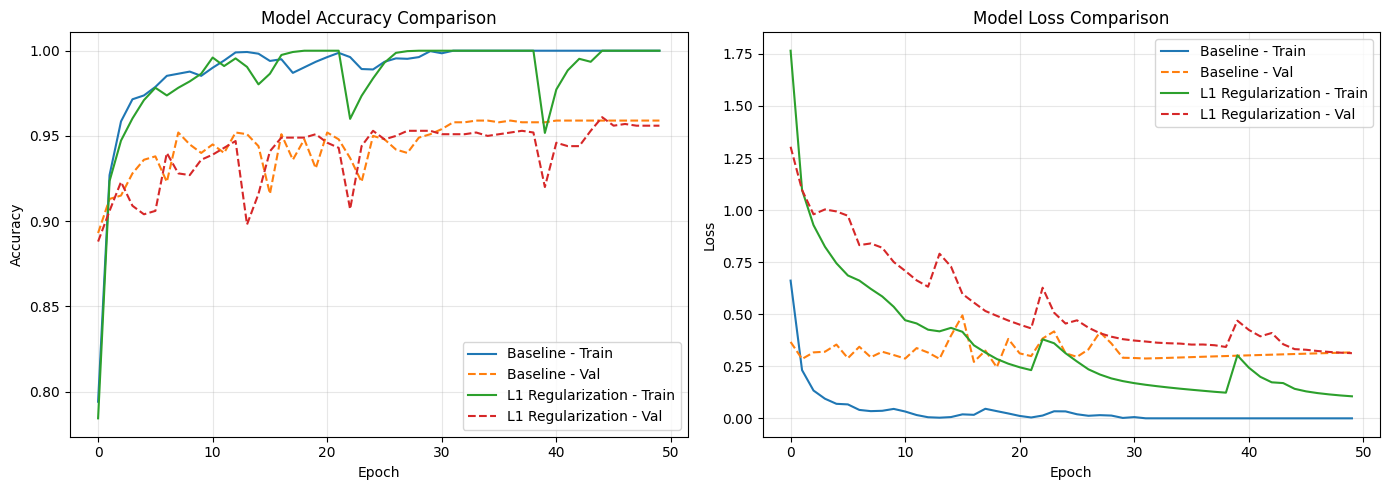

In [9]:
# Compare L1 with baseline
plot_training_history([baseline_history, l1_history], ['Baseline', 'L1 Regularization'])

In [10]:
# Analyze weight sparsity in L1 model
print("Analyzing weight sparsity in L1 regularized model:")
for i, layer in enumerate(l1_model.layers[:-1]):  # Exclude output layer
    weights = layer.get_weights()[0]
    zero_weights = np.sum(np.abs(weights) < 1e-6)
    total_weights = weights.size
    sparsity = (zero_weights / total_weights) * 100
    print(f"Layer {i+1}: {sparsity:.2f}% of weights are near zero")

Analyzing weight sparsity in L1 regularized model:
Layer 1: 1.35% of weights are near zero
Layer 2: 1.44% of weights are near zero
Layer 3: 1.27% of weights are near zero
Layer 4: 0.91% of weights are near zero


---
## 3. L2 Regularization (Ridge / Weight Decay)

L2 regularization adds the squared value of weights to the loss function. This encourages **smaller weights** but doesn't make them exactly zero.

**Mathematical formulation:**
$$\text{Loss}_{L2} = \text{Loss}_{original} + \lambda \sum_{i} w_i^2$$

**When to use:**
- When you want to prevent any single weight from having too much influence
- General-purpose regularization
- When all features are expected to be somewhat relevant

In [11]:
def create_l2_model(l2_strength=0.001):
    """
    Create a model with L2 regularization applied to all dense layers.

    Args:
        l2_strength: The regularization strength (lambda)
    """
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(784,),
                    kernel_regularizer=regularizers.l2(l2_strength)),
        layers.Dense(256, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_strength)),
        layers.Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_strength)),
        layers.Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_strength)),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create and train L2 regularized model
print("Training L2 Regularized Model...")
l2_model = create_l2_model(l2_strength=0.001)

l2_history = l2_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Training L2 Regularized Model...
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7918 - loss: 1.3449 - val_accuracy: 0.8820 - val_loss: 0.9775
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9212 - loss: 0.7819 - val_accuracy: 0.9090 - val_loss: 0.7845
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9498 - loss: 0.6368 - val_accuracy: 0.9210 - val_loss: 0.7013
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9613 - loss: 0.5534 - val_accuracy: 0.9100 - val_loss: 0.7461
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9680 - loss: 0.4994 - val_accuracy: 0.8980 - val_loss: 0.7959
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9753 - loss: 0.4488 - val_accuracy: 0.9310 - val_loss: 0.6261
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9840 - loss: 0.3966 - val_accuracy: 0.9080 - val_loss: 0.6988
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9858

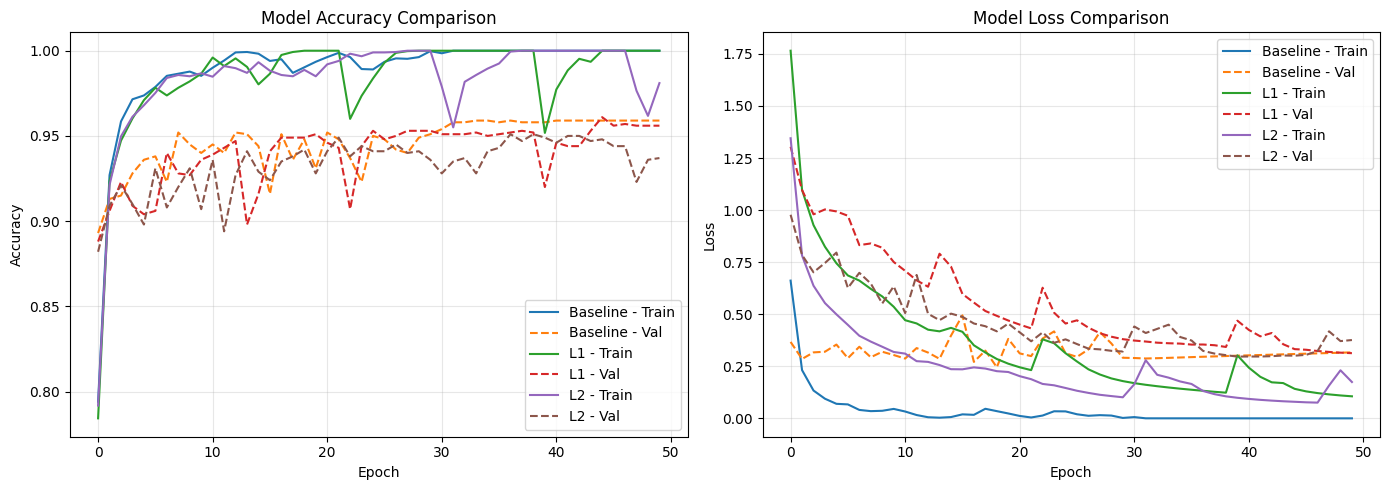

In [12]:
# Compare L2 with baseline and L1
plot_training_history(
    [baseline_history, l1_history, l2_history],
    ['Baseline', 'L1', 'L2']
)

---
## 4. Elastic Net (L1 + L2 Combined)

Elastic Net combines both L1 and L2 regularization, getting benefits of both: sparsity from L1 and small weights from L2.

**Mathematical formulation:**
$$\text{Loss}_{ElasticNet} = \text{Loss}_{original} + \lambda_1 \sum_{i} |w_i| + \lambda_2 \sum_{i} w_i^2$$

In [13]:
def create_elastic_net_model(l1_strength=0.0001, l2_strength=0.001):
    """
    Create a model with both L1 and L2 regularization (Elastic Net).
    """
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(784,),
                    kernel_regularizer=regularizers.l1_l2(l1=l1_strength, l2=l2_strength)),
        layers.Dense(256, activation='relu',
                    kernel_regularizer=regularizers.l1_l2(l1=l1_strength, l2=l2_strength)),
        layers.Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l1_l2(l1=l1_strength, l2=l2_strength)),
        layers.Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l1_l2(l1=l1_strength, l2=l2_strength)),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create and train Elastic Net model
print("Training Elastic Net (L1+L2) Model...")
elastic_model = create_elastic_net_model()

elastic_history = elastic_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Training Elastic Net (L1+L2) Model...
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7895 - loss: 2.3019 - val_accuracy: 0.8880 - val_loss: 1.6777
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9150 - loss: 1.4169 - val_accuracy: 0.8930 - val_loss: 1.4050
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9390 - loss: 1.1769 - val_accuracy: 0.9280 - val_loss: 1.1750
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9565 - loss: 1.0155 - val_accuracy: 0.9190 - val_loss: 1.0898
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9620 - loss: 0.9006 - val_accuracy: 0.9300 - val_loss: 1.0193
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9703 - loss: 0.8103 - val_accuracy: 0.9200 - val_loss: 0.9650
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9710 - loss: 0.7298 - val_accuracy: 0.9180 - val_loss: 0.8792
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0

---
## 5. Dropout Regularization

Dropout randomly "drops" (sets to zero) a fraction of neurons during training. This prevents neurons from co-adapting and forces the network to learn more robust features.

**Key concepts:**
- During training: randomly set neurons to 0 with probability p
- During inference: use all neurons but scale by (1-p)
- Keras handles the scaling automatically

In [14]:
def create_dropout_model(dropout_rate=0.5):
    """
    Create a model with Dropout layers.

    Args:
        dropout_rate: Fraction of neurons to drop (0-1)
    """
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(784,)),
        layers.Dropout(dropout_rate),
        layers.Dense(256, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create and train Dropout model
print("Training Dropout Model...")
dropout_model = create_dropout_model(dropout_rate=0.3)

dropout_history = dropout_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Training Dropout Model...
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5430 - loss: 1.2943 - val_accuracy: 0.8610 - val_loss: 0.4782
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8367 - loss: 0.5349 - val_accuracy: 0.9110 - val_loss: 0.3111
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8950 - loss: 0.3639 - val_accuracy: 0.9180 - val_loss: 0.2998
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9190 - loss: 0.2630 - val_accuracy: 0.9310 - val_loss: 0.2476
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9325 - loss: 0.2322 - val_accuracy: 0.9330 - val_loss: 0.2490
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9467 - loss: 0.1809 - val_accuracy: 0.9370 - val_loss: 0.2623
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9542 - loss: 0.1629 - val_accuracy: 0.9330 - val_loss: 0.3028
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9563 - loss

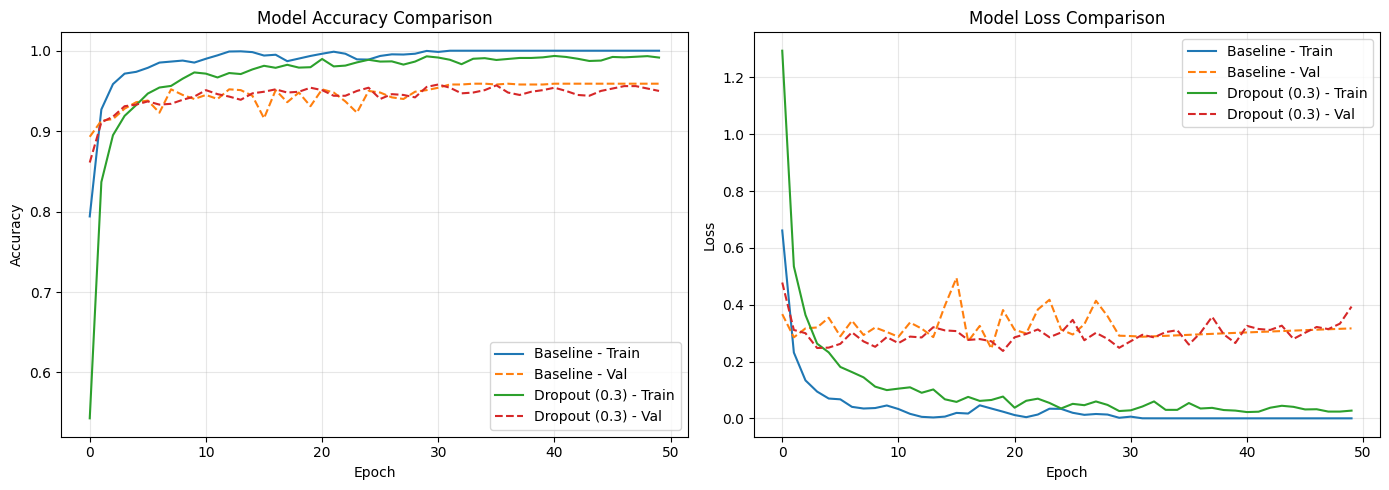

In [15]:
# Compare Dropout with baseline
plot_training_history(
    [baseline_history, dropout_history],
    ['Baseline', 'Dropout (0.3)']
)


A/B Testing Different Dropout Rates...

Training with dropout rate = 0.2

Training with dropout rate = 0.3

Training with dropout rate = 0.5


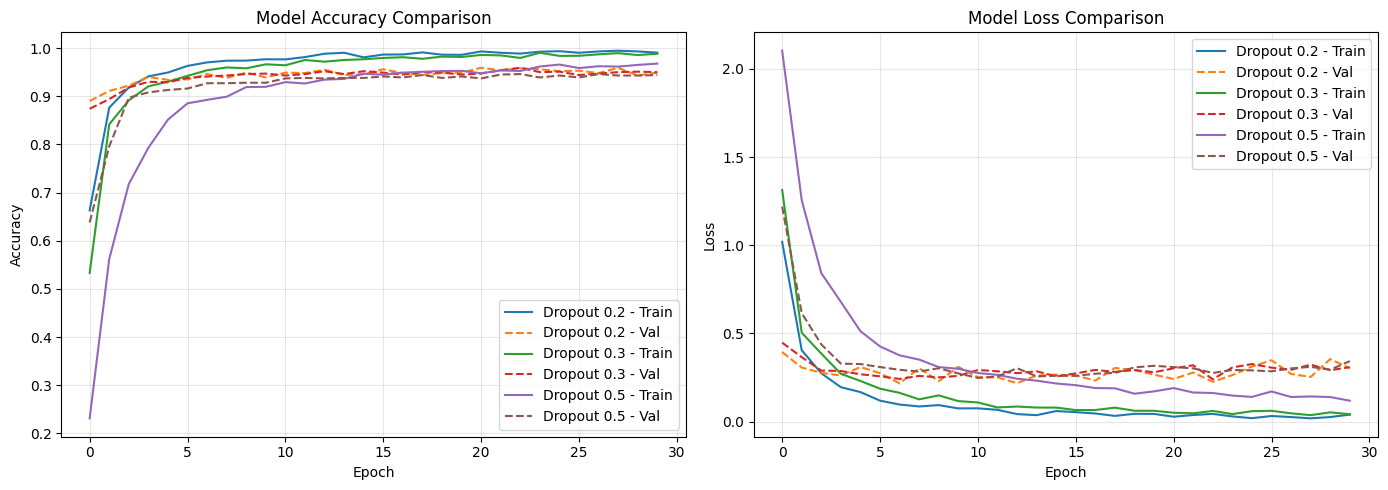

In [16]:
# A/B Test: Compare different dropout rates
print("\nA/B Testing Different Dropout Rates...")

dropout_rates = [0.2, 0.3, 0.5]
dropout_histories = []
dropout_labels = []

for rate in dropout_rates:
    print(f"\nTraining with dropout rate = {rate}")
    model = create_dropout_model(dropout_rate=rate)
    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=0
    )
    dropout_histories.append(history)
    dropout_labels.append(f'Dropout {rate}')

# Plot comparison
plot_training_history(dropout_histories, dropout_labels)

---
## 6. Early Stopping

Early Stopping monitors a metric (usually validation loss) and stops training when it stops improving. This prevents overfitting by stopping before the model memorizes the training data.

**Key parameters:**
- `monitor`: Metric to monitor (e.g., 'val_loss')
- `patience`: Number of epochs to wait for improvement
- `restore_best_weights`: Restore weights from the best epoch

In [17]:
# Create a new baseline model for early stopping demonstration
print("Training with Early Stopping...")
early_stop_model = create_baseline_model()

# Define early stopping callback
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',           # Monitor validation loss
    patience=5,                    # Wait 5 epochs for improvement
    min_delta=0.001,              # Minimum change to qualify as improvement
    restore_best_weights=True,     # Restore weights from best epoch
    verbose=1
)

# Train with early stopping
early_stop_history = early_stop_model.fit(
    X_train, y_train,
    epochs=100,  # Set high, early stopping will stop earlier
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

print(f"\nTraining stopped at epoch {len(early_stop_history.history['loss'])}")

Training with Early Stopping...
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7868 - loss: 0.6724 - val_accuracy: 0.8840 - val_loss: 0.4337
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9283 - loss: 0.2404 - val_accuracy: 0.9170 - val_loss: 0.2933
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9545 - loss: 0.1455 - val_accuracy: 0.9250 - val_loss: 0.2619
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9718 - loss: 0.0890 - val_accuracy: 0.9200 - val_loss: 0.3485
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9822 - loss: 0.0663 - val_accuracy: 0.9380 - val_loss: 0.2766
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9875 - loss: 0.0431 - val_accuracy: 0.9280 - val_loss: 0.3630
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9840 - loss: 0.0439 - val_accuracy: 0.9320 - val_loss: 0.3056
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

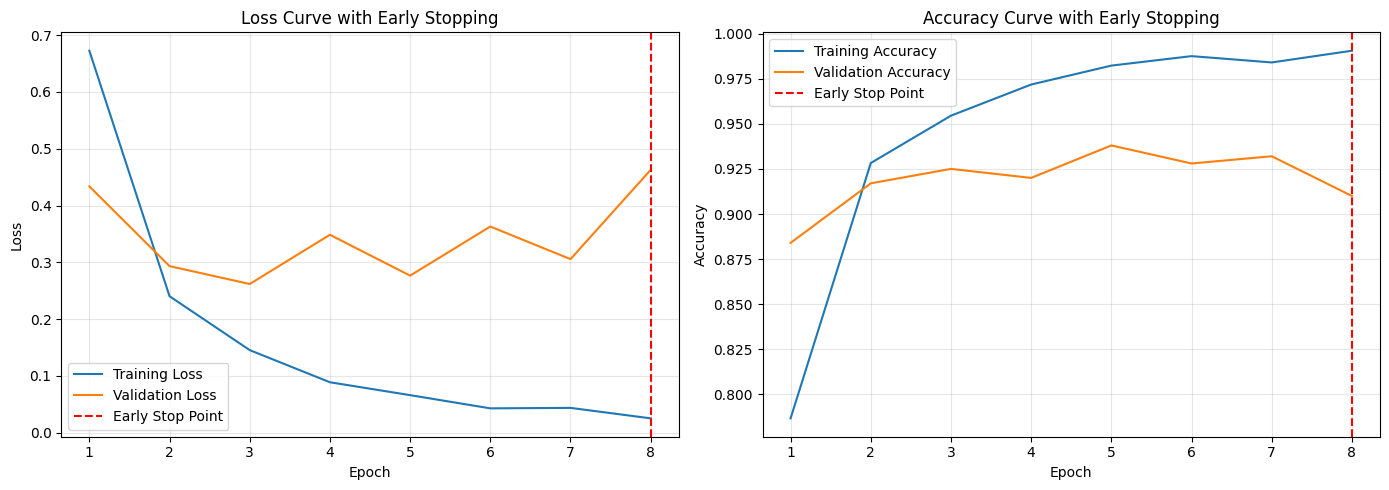

In [18]:
# Plot early stopping results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training curves
epochs = range(1, len(early_stop_history.history['loss']) + 1)
axes[0].plot(epochs, early_stop_history.history['loss'], label='Training Loss')
axes[0].plot(epochs, early_stop_history.history['val_loss'], label='Validation Loss')
axes[0].axvline(x=len(epochs), color='r', linestyle='--', label='Early Stop Point')
axes[0].set_title('Loss Curve with Early Stopping')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(epochs, early_stop_history.history['accuracy'], label='Training Accuracy')
axes[1].plot(epochs, early_stop_history.history['val_accuracy'], label='Validation Accuracy')
axes[1].axvline(x=len(epochs), color='r', linestyle='--', label='Early Stop Point')
axes[1].set_title('Accuracy Curve with Early Stopping')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Batch Normalization

Batch Normalization normalizes the inputs to each layer, making training faster and more stable. While primarily for optimization, it also has a slight regularization effect.

**How it works:**
1. Normalize inputs to have zero mean and unit variance
2. Scale and shift with learnable parameters (gamma and beta)

**Benefits:**
- Faster training
- Allows higher learning rates
- Reduces sensitivity to initialization
- Slight regularization effect

In [19]:
def create_batchnorm_model():
    """
    Create a model with Batch Normalization after each dense layer.
    Note: BatchNorm is typically placed BEFORE activation in modern practice.
    """
    model = keras.Sequential([
        layers.Dense(256, input_shape=(784,)),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create and train BatchNorm model
print("Training Batch Normalization Model...")
batchnorm_model = create_batchnorm_model()

batchnorm_history = batchnorm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Training Batch Normalization Model...
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8163 - loss: 0.6131 - val_accuracy: 0.9140 - val_loss: 0.5464
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9640 - loss: 0.1511 - val_accuracy: 0.9380 - val_loss: 0.2206
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9955 - loss: 0.0379 - val_accuracy: 0.9450 - val_loss: 0.1910
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9998 - loss: 0.0114 - val_accuracy: 0.9420 - val_loss: 0.1804
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9987 - loss: 0.0106 - val_accuracy: 0.9380 - val_loss: 0.2257
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9998 - loss: 0.0073 - val_accuracy: 0.9440 - val_loss: 0.2013
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.9450 - val_loss: 0.1925
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1

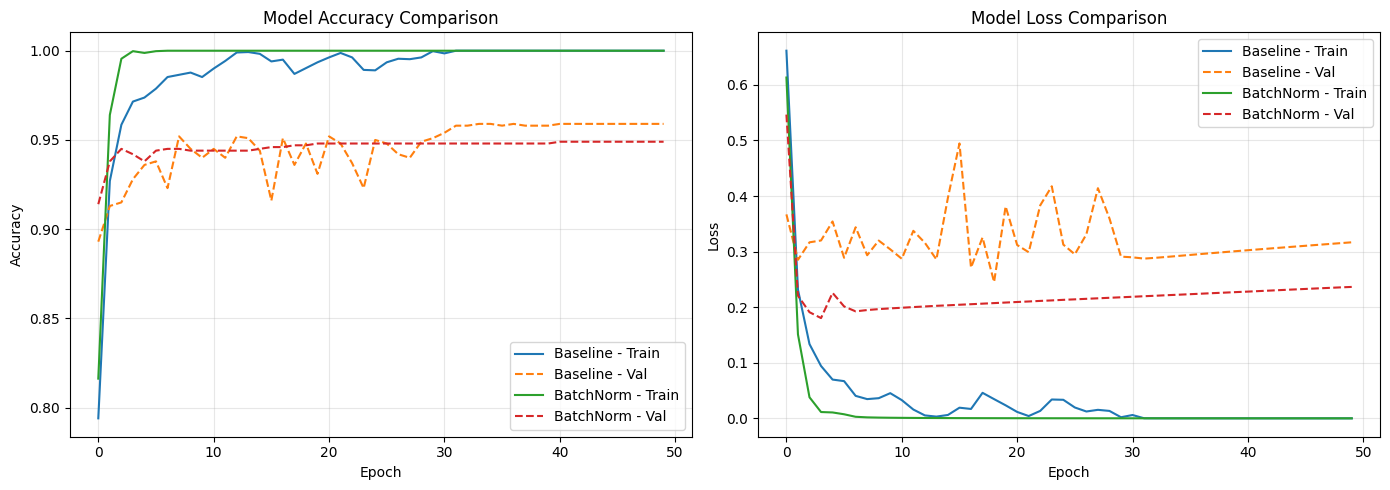

In [20]:
# Compare BatchNorm with baseline
plot_training_history(
    [baseline_history, batchnorm_history],
    ['Baseline', 'BatchNorm']
)

---
## 8. Combined Regularization

In practice, we often combine multiple regularization techniques for best results.

In [21]:
def create_fully_regularized_model():
    """
    Create a model with multiple regularization techniques:
    - L2 regularization
    - Dropout
    - Batch Normalization
    """
    model = keras.Sequential([
        layers.Dense(256, kernel_regularizer=regularizers.l2(0.001), input_shape=(784,)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(256, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(128, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(128, kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create and train fully regularized model with early stopping
print("Training Fully Regularized Model...")
full_reg_model = create_fully_regularized_model()

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

full_reg_history = full_reg_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Training Fully Regularized Model...
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.5527 - loss: 2.2178 - val_accuracy: 0.8800 - val_loss: 1.4510
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8020 - loss: 1.4059 - val_accuracy: 0.9110 - val_loss: 1.0679
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8583 - loss: 1.2162 - val_accuracy: 0.9180 - val_loss: 0.9860
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8913 - loss: 1.0669 - val_accuracy: 0.9230 - val_loss: 0.9324
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9115 - loss: 0.9537 - val_accuracy: 0.9310 - val_loss: 0.8870
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9135 - loss: 0.8981 - val_accuracy: 0.9340 - val_loss: 0.8434
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9305 - loss: 0.8217 - val_accuracy: 0.9420 - val_loss: 0.7874
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accur

---
## 9. Final Comparison: A/B Test Results

In [22]:
# Evaluate all models on test set
print("="*60)
print("FINAL TEST SET EVALUATION")
print("="*60)

models = [
    (baseline_model, "Baseline (No Regularization)"),
    (l1_model, "L1 Regularization"),
    (l2_model, "L2 Regularization"),
    (elastic_model, "Elastic Net (L1+L2)"),
    (dropout_model, "Dropout"),
    (early_stop_model, "Early Stopping"),
    (batchnorm_model, "Batch Normalization"),
    (full_reg_model, "Combined Regularization")
]

results = []
for model, name in models:
    loss, acc = evaluate_model(model, X_test, y_test, name)
    results.append((name, loss, acc))

print("\n" + "="*60)

FINAL TEST SET EVALUATION
Baseline (No Regularization): Test Loss = 0.3305, Test Accuracy = 0.9488
L1 Regularization: Test Loss = 0.3200, Test Accuracy = 0.9418
L2 Regularization: Test Loss = 0.3874, Test Accuracy = 0.9301
Elastic Net (L1+L2): Test Loss = 0.3719, Test Accuracy = 0.9321
Dropout: Test Loss = 0.4370, Test Accuracy = 0.9359
Early Stopping: Test Loss = 0.2788, Test Accuracy = 0.9142
Batch Normalization: Test Loss = 0.2655, Test Accuracy = 0.9410
Combined Regularization: Test Loss = 0.5347, Test Accuracy = 0.9360



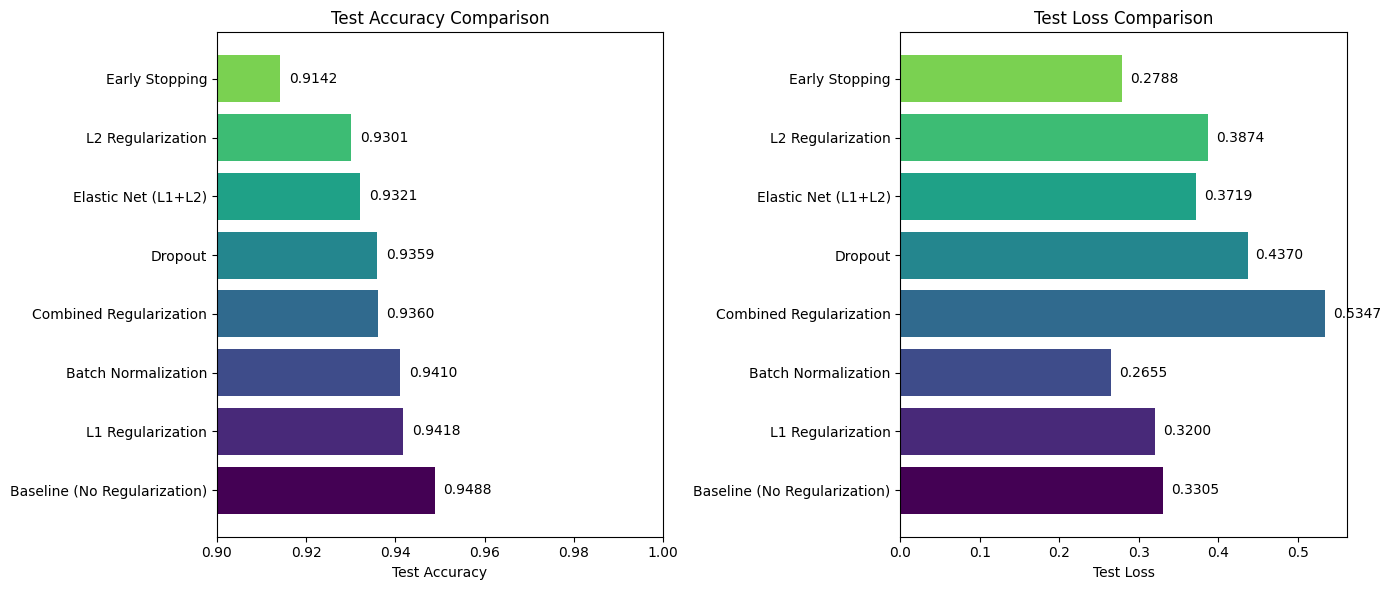


Results Table:
                       Model  Test Loss  Test Accuracy
Baseline (No Regularization)   0.330545         0.9488
           L1 Regularization   0.320008         0.9418
         Batch Normalization   0.265542         0.9410
     Combined Regularization   0.534740         0.9360
                     Dropout   0.436980         0.9359
         Elastic Net (L1+L2)   0.371915         0.9321
           L2 Regularization   0.387380         0.9301
              Early Stopping   0.278831         0.9142


In [23]:
# Visualize comparison
import pandas as pd

results_df = pd.DataFrame(results, columns=['Model', 'Test Loss', 'Test Accuracy'])
results_df = results_df.sort_values('Test Accuracy', ascending=False)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy comparison
colors = plt.cm.viridis(np.linspace(0, 0.8, len(results_df)))
bars1 = axes[0].barh(results_df['Model'], results_df['Test Accuracy'], color=colors)
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Test Accuracy Comparison')
axes[0].set_xlim(0.9, 1.0)
for bar, acc in zip(bars1, results_df['Test Accuracy']):
    axes[0].text(acc + 0.002, bar.get_y() + bar.get_height()/2,
                f'{acc:.4f}', va='center', fontsize=10)

# Loss comparison
bars2 = axes[1].barh(results_df['Model'], results_df['Test Loss'], color=colors)
axes[1].set_xlabel('Test Loss')
axes[1].set_title('Test Loss Comparison')
for bar, loss in zip(bars2, results_df['Test Loss']):
    axes[1].text(loss + 0.01, bar.get_y() + bar.get_height()/2,
                f'{loss:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nResults Table:")
print(results_df.to_string(index=False))

---
## Summary

### Key Takeaways:

| Technique | Purpose | When to Use |
|-----------|---------|-------------|
| **L1 Regularization** | Promotes sparsity | Feature selection, when many features are irrelevant |
| **L2 Regularization** | Prevents large weights | General-purpose, most common |
| **Dropout** | Prevents co-adaptation | Deep networks, large models |
| **Early Stopping** | Prevents overtraining | Always recommended to use |
| **Batch Normalization** | Stabilizes training | Deep networks, faster training |

### Best Practices:
1. Start with a baseline model to understand overfitting
2. Apply regularization incrementally
3. Use validation set to tune regularization strength
4. Combine multiple techniques for best results
5. Always use early stopping as a safety net